In [2]:
#librerias:
import pandas as pd
import os
from PIL import Image

# Instalacion

In [3]:
!pip install -q transformers accelerate pillow sentencepiece

In [4]:
from transformers import AutoProcessor
processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")
print("Processor cargado correctamente")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


...

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

Processor cargado correctamente


cargamos el modelo

In [5]:
from transformers import AutoProcessor, AutoModelForImageTextToText

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct")

model = AutoModelForImageTextToText.from_pretrained("HuggingFaceTB/SmolVLM-500M-Instruct",device_map="auto")

print("Modelo cargado")

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Modelo cargado


probamos que el modelo funcione bien y haga la descripcion de una imagen

In [6]:
from PIL import Image

image = Image.open("/content/drive/MyDrive/Lab_inteligencia/IC/01.jpg")


messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe this image in detail."}
        ]
    }
]

prompt = processor.apply_chat_template(messages,add_generation_prompt=True)

inputs = processor(text=prompt,images=image,return_tensors="pt")

inputs = {k: v.to(model.device) for k, v in inputs.items()}

generated_ids = model.generate(**inputs, max_new_tokens=150)

response = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(response)

User:



Describe this image in detail.
Assistant: The image depicts a coin with a circular shape and a prominent circular emblem in the center. The coin is predominantly gold in color and features a design that includes the number "500" and the word "PESOS" in large, bold letters. The number "500" is positioned in the center of the coin, with the word "PESOS" written in a smaller font below it. The coin also has a wreath of leaves encircling the emblem, which is a traditional design in many countries, symbolizing peace and unity.

The coin is placed on a textured surface, which appears to be a piece of fabric or a cloth. The surface has a light green color, and the edges of the coin are slightly worn


# Uso del modelo

In [ ]:
#Cargamos las descripciones:
df = pd.read_excel("descriptions.xlsx")


IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"
df["file_name"] = df["file_name"].str.replace('"', '')
df.head()


,file_name,manual_description_1,manual_description_2,manual_description_3,prompt_1,prompt_2,prompt_3
0,01.jpg,"""A close-up shot of a Chilean 500 pesos coin f...","""A macro photograph focusing on a Chilean 500 ...","""A high-detail macro shot where a Chilean 500-...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
1,02.jpg,"""A straight railway track stretching into the ...","""A ground-level perspective of a single railwa...","""A centered, wide-angle shot looking down a st...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
2,03.jpg,"""A close-up shot of an elderly person's wrinkl...","""A macro photograph focusing on the textured s...","""An intimate close-up capturing the weathered ...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
3,04.jpg,"""A wide shot of a vibrant golden sunset over t...","""A landscape photograph capturing a sunset ove...","""A stunning backlit seascape capturing the eph...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...
4,05.jpg,"""A field filled with bright yellow wildflower ...","""A medium-wide shot capturing a dense patch of...","""A vibrant landscape photograph showcasing a d...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...


In [9]:
from PIL import Image

def generate_caption(image_path, prompt_text):

    image = Image.open(image_path)

    messages = [{"role": "user","content":[{"type": "image"},{"type": "text", "text": prompt_text}]}]

    prompt = processor.apply_chat_template(messages,add_generation_prompt=True)

    inputs = processor(text=prompt, images=image, return_tensors="pt")

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    generated_ids = model.generate(**inputs, max_new_tokens=200)

    response = processor.batch_decode(generated_ids,skip_special_tokens=True)[0]

    # Limpiar formato conversacional
    if "Assistant:" in response:
        response = response.split("Assistant:", 1)[1]

    response = response.strip()

    return response

In [ ]:
#Definimos columnas para poner las respuestas del modelo en base a cada prompt
df["smolvlm_prompt1"] = "" #Descripcion del modelo en base al prompt 1
df["smolvlm_prompt2"] = "" #Descripcion del modelo en base al prompt 2
df["smolvlm_prompt3"] = "" #Descripcion del modelo en base al prompt 3

In [ ]:
#Probamos la funcion generate_caption con una imagen y prompt cualquiera

row = df.iloc[0]

image_path = os.path.join("/content/drive/MyDrive/Lab_inteligencia/IC", row["file_name"])
caption = generate_caption(image_path, row["prompt_1"])

print(caption)

The image depicts a coin with a circular shape and a circular edge. The coin is predominantly gold in color and features a design that includes a wreath of leaves and a laurel wreath around the edge. The wreath is made up of leaves that are evenly spaced and symmetrical. The wreath is encircling a central circle, which contains the number "500" in large, bold numerals. The number "500" is also inscribed in a smaller font below the central number.

The coin's edge is smooth and has a slightly raised surface, which is typical of coins used in many countries. The edge also features a small, circular emblem that appears to be a logo or a symbol, although the specific details of the emblem are not clearly visible.

The coin is placed on a textured surface, which appears to be a piece of fabric or a cloth. The fabric has a light green color and a slightly rough texture, suggesting it might be a piece of


In [ ]:
#Obtenemos las descripciones de forma iterativa:
for idx, row in df.iterrows():

    try:

        image_path = os.path.join(IMAGE_DIR,row["file_name"])

        print(f"\nProcesando {row['file_name']}")

        # Prompt 1
        desc1 = generate_caption(image_path,row["prompt_1"])

        df.loc[idx, "smolvlm_prompt1"] = desc1

        # Prompt 2
        desc2 = generate_caption(image_path,row["prompt_2"])

        df.loc[idx, "smolvlm_prompt2"] = desc2

        # Prompt 3
        desc3 = generate_caption(image_path, row["prompt_3"])

        df.loc[idx, "smolvlm_prompt3"] = desc3

        # Guardado de seguridad
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/smolvlm_resultados.xlsx", index=False)

        print("Completado")

    except Exception as e:

        print(f"Error en {row['file_name']}: {e}")


Procesando 01.jpg
Completado

Procesando 02.jpg
Completado

Procesando 03.jpg
Completado

Procesando 04.jpg
Completado

Procesando 05.jpg
Completado

Procesando 06.jpg
Completado

Procesando 07.jpg
Completado

Procesando 08.jpg
Completado

Procesando 09.jpg
Completado

Procesando 10.jpg
Completado

Procesando 11.jpg
Completado

Procesando 12.jpg
Completado

Procesando 13.jpg
Completado

Procesando 14.jpg
Completado

Procesando 15.jpg
Completado

Procesando 17.jpg
Completado

Procesando 18.jpg
Completado

Procesando 19.jpg
Completado

Procesando 20.jpg
Completado


En tiempo de ejecucion smolVLM se demora 10 minutos en procesar todas las imagenes, lo que se traduce en 10 segundos por imagen.

In [ ]:
#Cargamos data frame con las descripciones del modelo
import pandas as pd
df2 = pd.read_excel("/content/drive/MyDrive/Lab_inteligencia/smolvlm_resultados.xlsx")
df2.head()

,file_name,manual_description_1,manual_description_2,manual_description_3,prompt_1,prompt_2,prompt_3,smolvlm_prompt1,smolvlm_prompt2,smolvlm_prompt3
0,01.jpg,"""A close-up shot of a Chilean 500 pesos coin f...","""A macro photograph focusing on a Chilean 500 ...","""A high-detail macro shot where a Chilean 500-...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a coin with a circular shape...,The image depicts a coin with a circular desig...,The image depicts a coin with a golden-yellow ...
1,02.jpg,"""A straight railway track stretching into the ...","""A ground-level perspective of a single railwa...","""A centered, wide-angle shot looking down a st...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a railway track stretching i...,"The image depicts a long, straight railway tra...","The image depicts a long, straight railway tra..."
2,03.jpg,"""A close-up shot of an elderly person's wrinkl...","""A macro photograph focusing on the textured s...","""An intimate close-up capturing the weathered ...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts the hands of an elderly pers...,The image depicts the hands of an elderly pers...,The image depicts the hands of an elderly pers...
3,04.jpg,"""A wide shot of a vibrant golden sunset over t...","""A landscape photograph capturing a sunset ove...","""A stunning backlit seascape capturing the eph...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a serene coastal scene at su...,The image depicts a serene coastal scene at su...,The image depicts a serene coastal scene at su...
4,05.jpg,"""A field filled with bright yellow wildflower ...","""A medium-wide shot capturing a dense patch of...","""A vibrant landscape photograph showcasing a d...","""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image depicts a field of flowers, predomin...",The image depicts a vibrant and lush field of ...,The image depicts a vibrant and lush field of ...


ahora calculamos la similitud de cada caption con su respectivo ground truth

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_similarity(text1, text2):

    emb1 = embedding_model.encode(text1, convert_to_numpy=True)
    emb2 = embedding_model.encode(text2, convert_to_numpy=True)

    return cosine_similarity([emb1],[emb2])[0][0]

# Creamos 3 columnas nuevas para guardar la similitud entre la descripcion hecha por el modelo y la descripcion ground truth

df2["sim_prompt1"] = 0.0
df2["sim_prompt2"] = 0.0
df2["sim_prompt3"] = 0.0

In [ ]:
for idx, row in df2.iterrows():

    df2.loc[idx, "sim_prompt1"] = semantic_similarity(row["manual_description_1"], row["smolvlm_prompt1"])

    df2.loc[idx, "sim_prompt2"] = semantic_similarity(row["manual_description_2"], row["smolvlm_prompt2"])

    df2.loc[idx, "sim_prompt3"] = semantic_similarity(row["manual_description_3"], row["smolvlm_prompt3"])

In [ ]:
df2[["file_name","sim_prompt1","sim_prompt2","sim_prompt3"]]

,file_name,sim_prompt1,sim_prompt2,sim_prompt3
0,01.jpg,0.437661,0.570003,0.619393
1,02.jpg,0.605112,0.775445,0.768299
2,03.jpg,0.543061,0.578240,0.732067
3,04.jpg,0.758130,0.829005,0.791882
4,05.jpg,0.685742,0.667663,0.763540
5,06.jpg,0.509387,0.550348,0.643078
6,07.jpg,0.632317,0.597980,0.615301
7,08.jpg,0.558137,0.702034,0.742345
8,09.jpg,0.648733,0.806532,0.654138
9,10.jpg,0.335230,0.685753,0.515172


In [ ]:
print("Similitud promedio por cada columna:")
print("Prompt 1:", df2["sim_prompt1"].mean())
print("Prompt 2:", df2["sim_prompt2"].mean())
print("Prompt 3:", df2["sim_prompt3"].mean())

Similitud promedio por cada columna:
Prompt 1: 0.5968215904737774
Prompt 2: 0.6897150497687491
Prompt 3: 0.6945473990942302


Ahora visualizamos una imagen con su caption y su caption ground truth

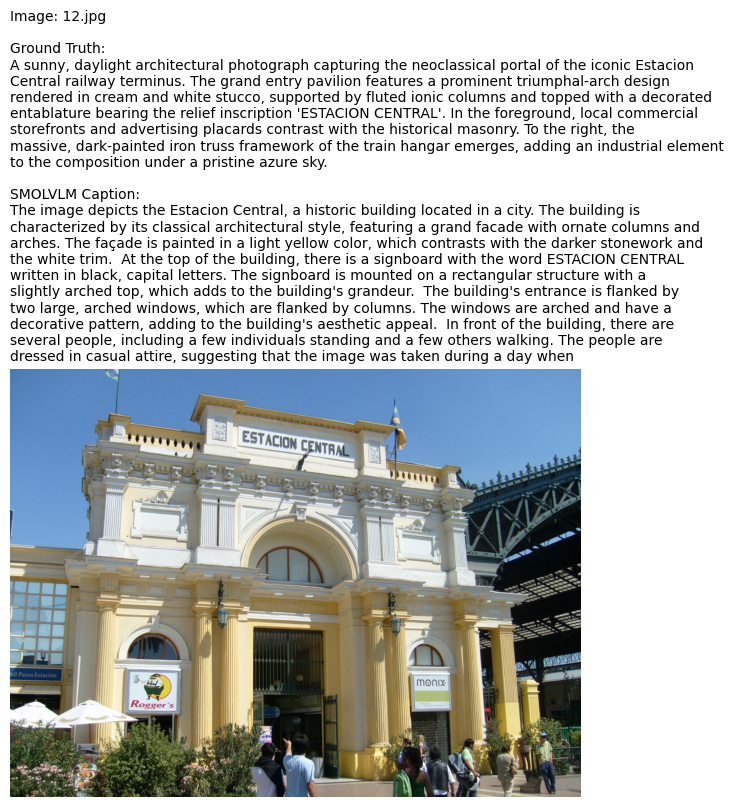

In [ ]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Rutas
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/IC"
EXCEL_PATH = "/content/resultados_llama final.xlsx"



def plot_image_with_captions(df,index,prompt_id,model_name,image_dir=IMAGE_DIR, wrap_width=100):
    """
    index: índice de la fila en el DataFrame
    prompt_id: 1, 2 o 3
    model_name: por ejemplo "llama", "qwen" o "smolvlm"
    """

    row = df.iloc[index]

    file_name = row["file_name"]
    image_path = os.path.join(image_dir, file_name)

    manual_col = f"manual_description_{prompt_id}"
    model_col = f"{model_name}_prompt{prompt_id}"

    manual_caption = str(row[manual_col]).replace('"', '').strip()
    model_caption = str(row[model_col]).replace('"', '').strip()

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Image: {file_name}\n\n"
        f"Ground Truth:\n{textwrap.fill(manual_caption, wrap_width)}\n\n"
        f"{model_name.upper()} Caption:\n{textwrap.fill(model_caption, wrap_width)}"
    )

    plt.title(title, fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()



plot_image_with_captions(df2, index=11, prompt_id=3, model_name="smolvlm")

# OCR

In [8]:
#Cargamos Data frame con las imagenes de OCR:
import pandas as pd

df =pd.read_excel("descripciones_OCR.xlsx")
df["smolvlm_prompt1"] = ""
df["smolvlm_prompt2"] = ""
df["smolvlm_prompt3"] = ""
df.head()

,file_name,prompt_1,prompt_2,prompt_3,smolvlm_prompt1,smolvlm_prompt2,smolvlm_prompt3
0,20220101_035959.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
1,20230214_122422.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
2,20230430_150424.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
3,20230511_133754.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,
4,20230811_151805.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,,,


In [11]:
#Obtenemos las descripciones de forma iterativa:
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/OCR"

for idx, row in df.iterrows():

    try:

        image_path = os.path.join(IMAGE_DIR,row["file_name"])

        print(f"\nProcesando {row['file_name']}")

        # Prompt 1
        desc1 = generate_caption(image_path,row["prompt_1"])

        df.loc[idx, "smolvlm_prompt1"] = desc1

        # Prompt 2
        desc2 = generate_caption(image_path,row["prompt_2"])

        df.loc[idx, "smolvlm_prompt2"] = desc2

        # Prompt 3
        desc3 = generate_caption(image_path, row["prompt_3"])

        df.loc[idx, "smolvlm_prompt3"] = desc3

        # Guardado de seguridad
        df.to_excel("/content/drive/MyDrive/Lab_inteligencia/smolvlm_resultados_OCR.xlsx", index=False)

        print("Completado")

    except Exception as e:

        print(f"Error en {row['file_name']}: {e}")


Procesando 20220101_035959.jpg
Completado

Procesando 20230214_122422.jpg
Completado

Procesando 20230430_150424.jpg
Completado

Procesando 20230511_133754.jpg
Completado

Procesando 20230811_151805.jpg
Completado

Procesando 20231108_090334.jpg
Completado

Procesando 20240401_124930.jpg
Completado

Procesando 20240603_120302.jpg
Completado

Procesando 20250331_130243.jpg
Completado

Procesando 20250819_074858.jpg
Completado

Procesando 20250819_074905.jpg
Completado

Procesando 20250908_140611.jpg
Completado

Procesando 20250908_154959.jpg
Completado

Procesando 20250908_155938.jpg
Completado

Procesando 20250908_160638.jpg
Completado


In [13]:
#Cargamos data frame con los resultados:
df_ocr = pd.read_excel("/content/drive/MyDrive/Lab_inteligencia/smolvlm_resultados_OCR.xlsx")
df_ocr.head()

,file_name,prompt_1,prompt_2,prompt_3,smolvlm_prompt1,smolvlm_prompt2,smolvlm_prompt3
0,20220101_035959.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a signboard mounted on a wal...,The image depicts a blue sign affixed to a wal...,The image depicts a blue rectangular sign affi...
1,20230214_122422.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a historical building with a...,A large blue sign is hanging from a window of ...,The image depicts a prominent outdoor signboar...
2,20230430_150424.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image depicts a glass plaque with a detail...,The image depicts a clear glass plaque with th...,"The image depicts a clear, transparent glass p..."
3,20230511_133754.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,"The image depicts a rectangular, black, digita...","The image shows a rectangular, black, electron...","The image depicts a rectangular, black, metall..."
4,20230811_151805.jpg,"""Describe the given image in general terms.""","""Provide a clear description of the image. Ide...",Perform an exhaustive and highly detailed anal...,The image is a historical document or a poster...,The image is a wall with text and a photograph...,The image is a wall-mounted informational plaq...


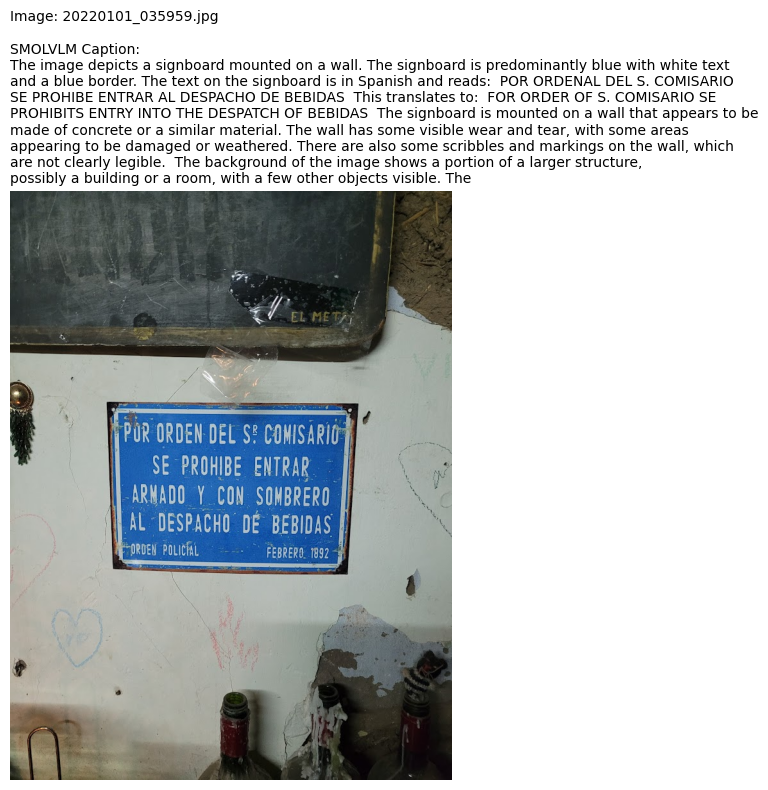

In [14]:
import os
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Rutas
IMAGE_DIR = "/content/drive/MyDrive/Lab_inteligencia/OCR"


def plot_image_with_captions(df,index,prompt_id,model_name,image_dir=IMAGE_DIR, wrap_width=100):
    """
    index: índice de la fila en el DataFrame
    prompt_id: 1, 2 o 3
    model_name: por ejemplo "llama", "qwen" o "smolvlm"
    """

    row = df.iloc[index]

    file_name = row["file_name"]
    image_path = os.path.join(image_dir, file_name)


    model_col = f"{model_name}_prompt{prompt_id}"
    model_caption = str(row[model_col]).replace('"', '').strip()

    image = Image.open(image_path).convert("RGB")

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis("off")

    title = (
        f"Image: {file_name}\n\n"
        f"{model_name.upper()} Caption:\n{textwrap.fill(model_caption, wrap_width)}"
    )

    plt.title(title, fontsize=10, loc="left")
    plt.tight_layout()
    plt.show()



plot_image_with_captions(df_ocr, index=0, prompt_id=1, model_name="smolvlm")